In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.seterr(over='ignore', invalid='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

# Projeto 2 - Jacobi e Gauss-Seidel

Modelo de entrega.

Respeite as divisões em Markdown para facilitar a navegação no relatório.

## Questão 1a: Implementação

Implemente os métodos de Jacobi e Gauss-Seidel para resolver o sistema linear $Ax = b$.

In [3]:
# Código
def jacobi(A, b, tol=1e-12, max_iter=1000):
    # Palpite inicial
    x_k = np.zeros(b.size)
    
    # Dividir A em L, D e U
    d = np.diag(A)
    D = np.diag(d)
    L_plus_U = (A - D)
    
    x_errors = []
    residual_errors = []
    
    # Implementando as iterações
    for _ in range(max_iter):
        # Dividir elemento a elemento as linhas pelo vetor d é o mesmo que multiplicar por D^(-1)
        x_k_plus_1 = (b - L_plus_U @ x_k) / d    
    
        # Calculando os erros associados a cada iteração
        delta_steps = np.linalg.norm(x_k_plus_1 - x_k)
        residual_norm = np.linalg.norm(b - A @ x_k_plus_1)
    
        x_errors.append(delta_steps)
        residual_errors.append(residual_norm)

        # Atualizando o palpite
        x_k = x_k_plus_1
        
        # Verificando se o método já convergiu o suficiente
        if (delta_steps < tol) or (residual_norm < tol):
            break

    return x_k, np.array(x_errors), np.array(residual_errors)

#===============================================================
#===============================================================
#===============================================================

def gauss_seidel(A, b, tol=1e-12, max_iter=1000):
    b_size = b.size
    
    # Palpite inicial
    x_k = np.zeros(b_size)
    # Inicializando o x da próxima iteração
    x_k_plus_1 = np.zeros(b_size)
    
    x_errors = []
    residual_errors = []
    
    # Implementando as iterações
    for _ in range(max_iter):
                
        for i in range(b_size):
            aux_x_k = A[i, (i+1):] @ x_k[(i+1):]
                
            aux_x_k_plus_1 = A[i, :i] @ x_k_plus_1[:i]
                
            x_k_plus_1[i] = (b[i] - aux_x_k - aux_x_k_plus_1) / A[i, i]
        
        # Calculando os erros associados a cada iteração
        delta_steps = np.linalg.norm(x_k_plus_1 - x_k)
        residual_norm = np.linalg.norm(b - A @ x_k_plus_1)
    
        x_errors.append(delta_steps)
        residual_errors.append(residual_norm)
        
        x_k = x_k_plus_1.copy()
        
        # Verificando se o método já convergiu o suficiente
        if (delta_steps < tol) or (residual_norm < tol):
            break
    
    return x_k, np.array(x_errors), np.array(residual_errors)

Qual deveria ser a complexidade computacional do código que você escreveu?

## Método de Jacobi
Considere $A$ uma matriz $n \times n$
Na função referente a esse método, calculei a complexidade separadamente:
- **Pré-loop**: Aqui, calculei uma complexidade de $2n^2 + 2n + 5$ apenas contando as operações feitas. Assim, essa parte tem uma complexidade associada de $O(n^2)$.

- **Loop**: Nessa parte é a que de fato fazemos os cálculos com os vetores e matrizes. Desse modo, analisando a equação de iteração, fazemos nela uma multiplicação de matriz com vetor, uma subtração de vetores e uma divisão de cada elemento do vetor. Logo, esse componente vai ter um custo de $(2n -1) \cdot n + n + n = 2n^2 + n$, ou seja, complexidade $O(n^2)$. Além disso, na parte de calcular o ```delta_step``` (norma da subtração de dois vetores) teremos que fazer $2n + 1$ operações, resultando em uma complexidade de $O(n)$. Aliás, no próximo cálculo da norma há uma multiplicação de matriz por vetor, aumentando a complexidade dessa operação para $O(n^2)$. No restante, são apenas custos constantes.

Portanto, no final das contas, a complexidade de uma iteração desse algoritmo implementado é de $O(n^2)$. Como o algoritmo executa $k$ iterações até que o critério de convergência seja atingido (onde $k$ depende da matriz e da tolerância exigida), a complexidade computacional total do algoritmo de Jacobi implementado é de $O(k \cdot n^2)$.

## Método de Gauss-Seidel
Considere, de novo, uma matriz $A_{n \times n}$.
Vamos seguir o mesmo raciocínio:
- **Pré-Loop**: Aqui a complexidade já é menor que do método de Jacobi, pois são feitas: uma operação com custo 1, duas com custo $n$ e duas com custo 1. Assim, essa parte tem complexidade $O(n)$.

- **Loop**: Agora fazemos as iterações e calculamos sequencialmente o $x^{(k+1)}$. Isso porque, diferentemente de Jacobi, para implementar esse método com a inversa de $(D+L)$ nos custaria uma complexidade $O(n^3)$, e é exatamente isso que queremos evitar. Dessa forma, em cada iteração vai nos custar: $2n^2 + 3n$ pelas operações de calcular ```aux_x_k``` e ```aux_x_k_plus_1``` e $2n^2 + 4n + 6$ pelas operações de calcular os erros (há uma multiplicação de matriz por vetor, adicionando o termo quadrático) e atribuições. Logo, a complexidade de cada iteração é $O(n^2)$.

Portanto, considerando $k$ iterações até o critério de convergência ser atingido, temos que a complexidade computacional do algoritmo de Gauss-Seidel implementado é de $O(k \cdot n^2)$.

## Questão 1b: Testes
Teste com matrizes $2 \times 2$ e $3 \times 3$, e compare graficamente a velocidade de convergência dos dois métodos.

In [4]:
# Função para comparar os métodos para matrizes pequenas
def comparar_metodos_b(A, b):
    # Gerando matrizes com diagonal dominante para garantir a convergência dos métodos:
    x_j, errors_j, residual_errors_j = jacobi(A, b)
    x_gs, errors_gs, residual_errors_gs = gauss_seidel(A, b)
    x_correto = np.linalg.solve(A, b)
    
    # Printando e plotando as informações
    print(f"Resposta correta: {x_correto}\nSolução encontrada em cada método:\nJacobi: {x_j}\nGauss_Seidel: {x_gs}")
    plt.figure()
    sns.lineplot(data=residual_errors_j, label="Método de Jacobi")
    sns.lineplot(data=residual_errors_gs, label="Método de Gauss_Seidel")
    plt.title("Comparação da velocidade de convergência")
    plt.xlabel("Número de iterações")
    plt.ylabel("Erro Residual")
    plt.yscale("log")
    plt.show()

## Testes para matrizes 2x2
**Observação**: Escolhi matrizes com diagonal dominante para os métodos convergirem.

Resposta correta: [1. 2.]
Solução encontrada em cada método:
Jacobi: [1. 2.]
Gauss_Seidel: [1. 2.]


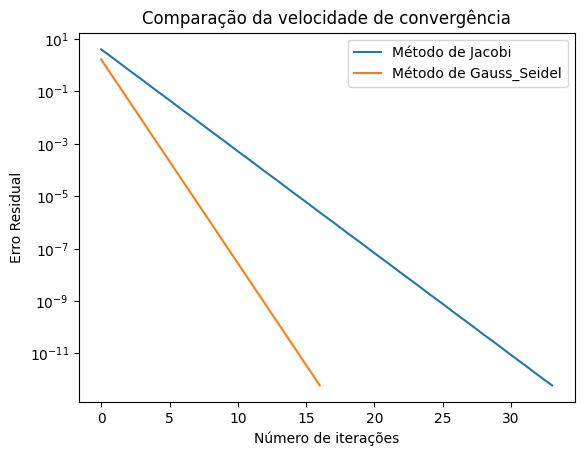

Resposta correta: [2. 1.]
Solução encontrada em cada método:
Jacobi: [2. 1.]
Gauss_Seidel: [2. 1.]


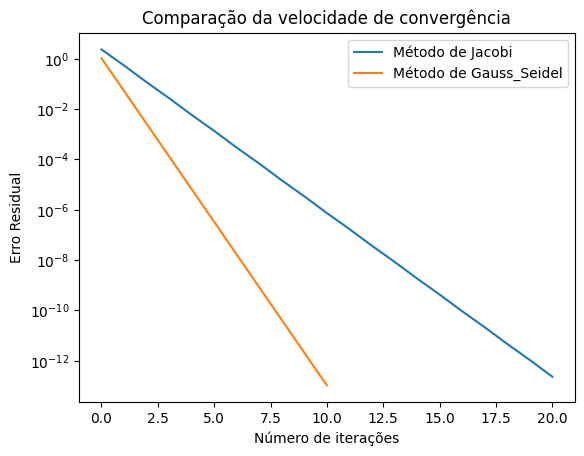

Resposta correta: [ 3. -1.]
Solução encontrada em cada método:
Jacobi: [ 3. -1.]
Gauss_Seidel: [ 3. -1.]


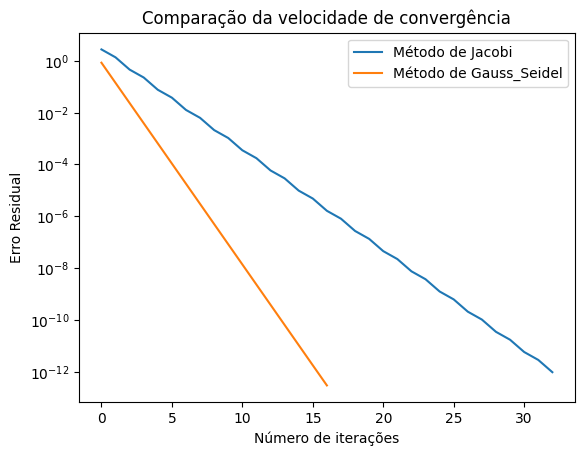

In [5]:
b_1, A_1 = np.array([6, 8]), np.array([[4,1],[2,3]])
b_2, A_2 = np.array([9, 6]), np.array([[5,-1],[1,4]])
b_3, A_3 = np.array([8, 1]), np.array([[3,1],[1,2]])

comparar_metodos_b(A_1, b_1)
comparar_metodos_b(A_2, b_2)
comparar_metodos_b(A_3, b_3)

## Testes para matrizes 3x3

Resposta correta: [1. 2. 3.]
Solução encontrada em cada método:
Jacobi: [1. 2. 3.]
Gauss_Seidel: [1. 2. 3.]


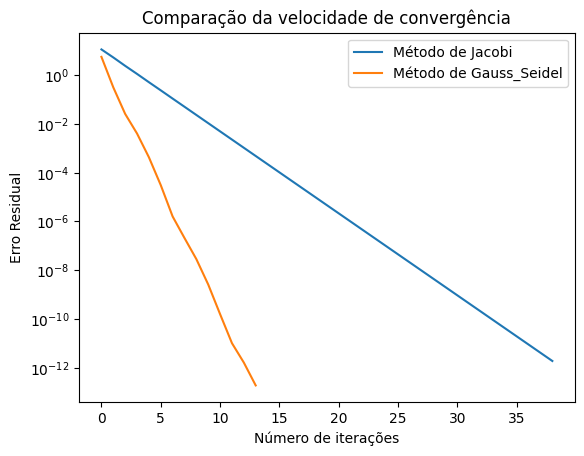

Resposta correta: [2. 1. 1.]
Solução encontrada em cada método:
Jacobi: [2. 1. 1.]
Gauss_Seidel: [2. 1. 1.]


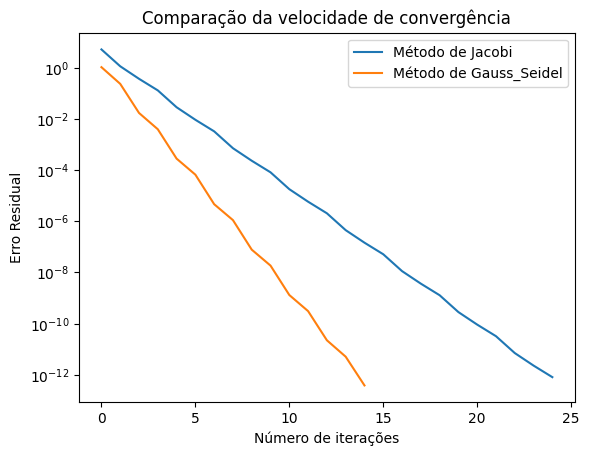

Resposta correta: [ 1. -1.  2.]
Solução encontrada em cada método:
Jacobi: [ 1. -1.  2.]
Gauss_Seidel: [ 1. -1.  2.]


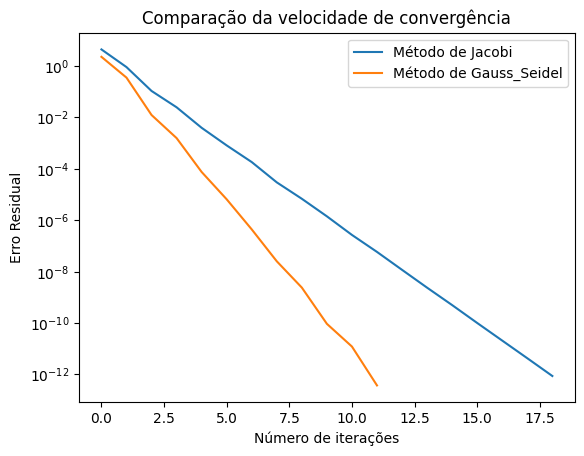

In [6]:
b_1, A_1 = np.array([10, 17, 15]), np.array([[5, 1, 1],[2, 6, 1],[1, 1, 4]])
b_2, A_2 = np.array([8, 6, 11]), np.array([[4, -1, 1],[1, 5, -1],[2, 1, 6]])
b_3, A_3 = np.array([5, -3, 12]), np.array([[6, 1, 0],[2, 7, 1],[1, -1, 5]])

comparar_metodos_b(A_1, b_1)
comparar_metodos_b(A_2, b_2)
comparar_metodos_b(A_3, b_3)

## Comentários
Os dois métodos convergiram à resposta correta em todos os casos. Mas é possível notar que em ambas situações (matrizes 2x2 e matrizes 3x3) o método de Gauss-Siedel foi mais eficiente e convergiu mais rapidamente que o método de Jacobi. Porém, essa diferença, por enquanto nessas dimensões, foi pequena.

## Questão 1c: Matrizes maiores
Teste com matrizes maiores.  Estes métodos funcionam para matrizes do tipo `rand(m,m)`?

In [7]:
# Função para comparar os métodos com matrizes rand(m,m) maiores
def comparar_metodos_c(A, b, max_iter=10000): 
    # Gerando matrizes com diagonal dominante para garantir a convergência dos métodos:
    x_j, errors_j, residual_errors_j = jacobi(A, b, max_iter=max_iter, tol=1e-17)
    x_gs, errors_gs, residual_errors_gs = gauss_seidel(A, b, max_iter=max_iter, tol=1e-17)
    
    # Printando e plotando as informações
    plt.figure()
    sns.lineplot(data=residual_errors_j, label="Método de Jacobi")
    sns.lineplot(data=residual_errors_gs, label="Método de Gauss_Seidel")
    plt.title(f"Velocidade de convergência (shape={A.shape})")
    plt.yscale("log")
    plt.xscale("log")
    plt.xlabel("Número de Iterações")
    plt.ylabel("Erro Residual")
    plt.legend(loc="upper right")
    plt.show()

## Matrizes maiores com diagonal dominante

In [ ]:
def get_mat_diag_dom(size):
    A = np.random.rand(size, size)
    
    # Tornando a diagonal dominante
    for i in range(size):
        A[i,i] += np.sum(np.abs(A[i,:]))
        
    return A

# Para garantir que b esteja no espaço coluna de A
def get_b(A):
    x = np.random.rand(A.shape[0])
    b = A @ x
    return b

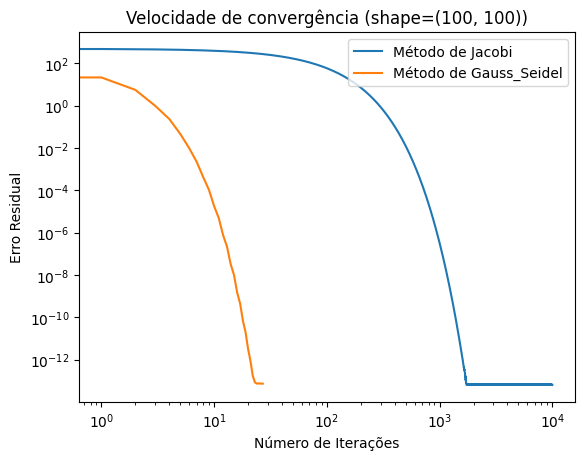

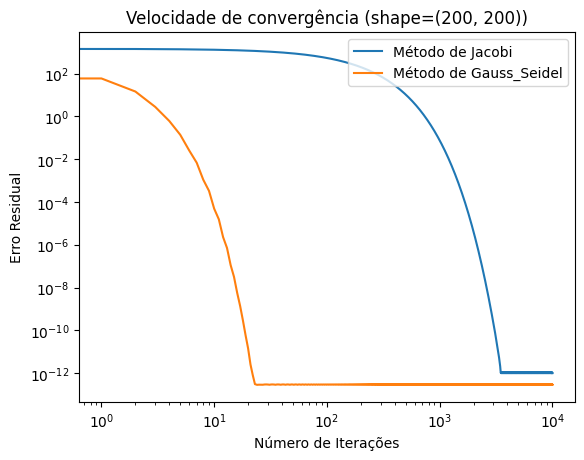

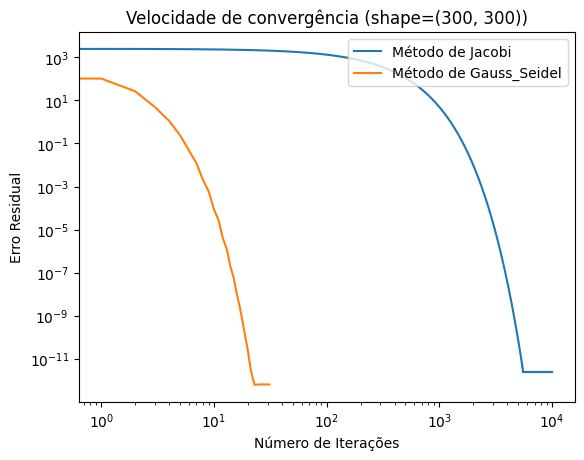

In [9]:
A_1 = get_mat_diag_dom(100)
A_2 = get_mat_diag_dom(200)
A_3 = get_mat_diag_dom(300)

comparar_metodos_c(A_1, get_b(A_1))
comparar_metodos_c(A_2, get_b(A_2))
comparar_metodos_c(A_3, get_b(A_3))

## Matrizes maiores do tipo ```rand(m,m)```

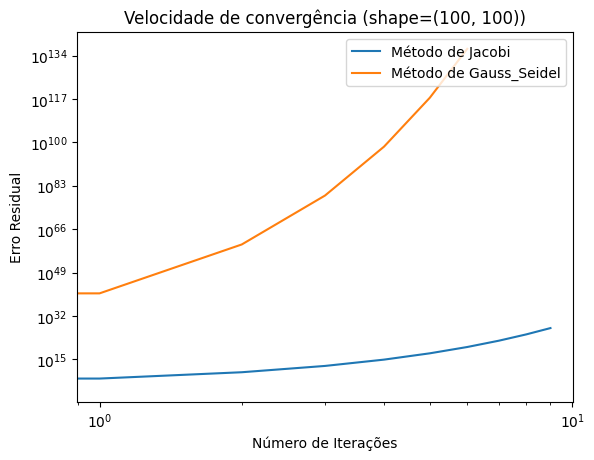

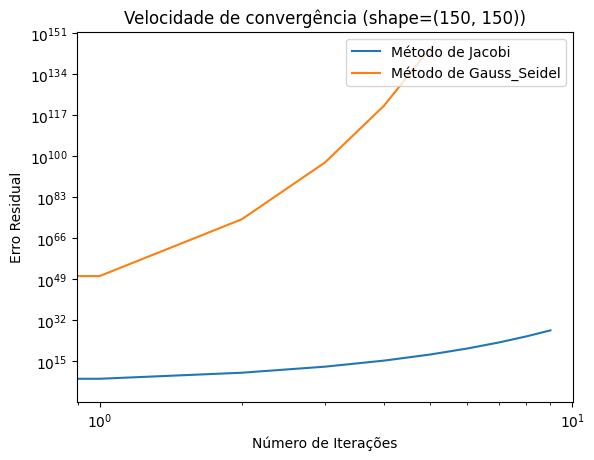

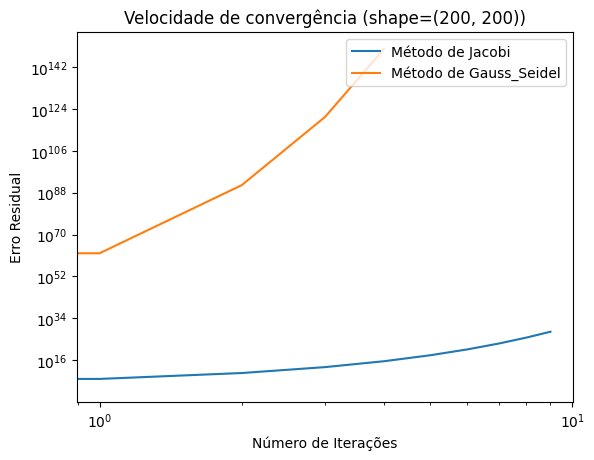

In [14]:
b_1, A_1 = np.random.rand(100), np.random.rand(100, 100)
b_2, A_2 = np.random.rand(150), np.random.rand(150, 150)
b_3, A_3 = np.random.rand(200), np.random.rand(200, 200)

comparar_metodos_c(A_1, get_b(A_1), max_iter=10)
comparar_metodos_c(A_2, get_b(A_2), max_iter=10)
comparar_metodos_c(A_3, get_b(A_3), max_iter=10)

## Comentários
Em geral, percebemos que se nós não normalizarmos a matriz randomizada para ter diagonal dominante, os métodos irão divergir. Ao contrário, se a matriz tiver diagonal dominante, vemos que os métodos continuam funcionando e o Gauss_Seidel continua apresentando uma eficiência muito melhor que o Jacobi (este último leva milhares de iterações a mais para convergir até certo erro de tolerância que nos testes foi de $10^{-12}$)

## Questão 1d: Matrizes maiores ainda!
Quão grande deve ser $k(m)$ para funcionar para 95\% das matrizes do tipo `randn(m,m)` + $ k(m) \cdot I_m$?  Quais velocidades de convergência você observa para este $k(m)$?

In [11]:
# Código (gerando possivelmente gráficos ou tabelas)

(Comentários)

## Questão 1e: Jacobi vs Gauss-Seidel
Encontre uma matriz $A$ $4 \times 4$ para a qual o método de Jacobi tenha melhor convergência que o método de Gauss-Seidel.

(Explique suas ideias, verifique abaixo)

In [12]:
# Código

## Questão 1f: Perturbações
O que acontece se você somar uma matriz aleatória e pequena à matriz $A$ acima?  O que acontece se esta perturbação acontecer apenas fora da diagonal?

In [13]:
# Código

(Comentários)